# Notebook 3 — Sequence-to-sequence with autoregressive recurrent models + attention

This notebook follows the **recipe card for autoregressive seq2seq + attention**.

**Task:** given the first part of an ECG signal, predict the future part of the same signal.

We again use **ECG5000**, a small biomedical time-series dataset.  
Each original sample is one ECG sequence of length `140`.  
We split each sequence into:

- **input sequence**: first `T_x = 90` time steps
- **target output sequence**: last `T_y = 50` time steps

So each training sample is:

- `x_i in R^[T_x x F_x]`
- `y_i in R^[T_y x F_y]`

Here the signal is univariate, so:

- `F_x = 1`
- `F_y = 1`

The model is now an **encoder-decoder recurrent model with attention**:

`x -> Encoder -> all encoder hidden states H -> Attention at each decoder step -> Decoder -> y_hat_1, ..., y_hat_Ty`

The decoder is still **autoregressive**:

- during training, it can use the **true previous target** (**teacher forcing**)
- during inference, it uses its **own previous prediction**

The main change from the previous notebook is that we no longer compress the input into one fixed context vector.  
Instead, at each decoder step, the model computes a **step-specific context vector** with attention.

## 1. Load libraries

We use standard Python tools, PyTorch, and a few utilities for plotting and data splitting.

In [1]:

# ---------------------------------------
# 1) Load libraries
# ---------------------------------------
from pathlib import Path
import urllib.request
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Load your sequence dataset `D`

For an autoregressive seq2seq task, each training sample is a pair:

`D = {(x_1, y_1), ..., (x_k, y_k)}`

where:

- `x_i in R^[T_x x F_x]`: input sequence
- `y_i in R^[T_y x F_y]`: target output sequence

In this notebook, each ECG signal has length `140`.  
We split it into:

- input prefix: `T_x = 90`
- future target suffix: `T_y = 50`

So the model must read the observed prefix and generate the future suffix.

In [4]:

# ---------------------------------------
# 2) Load ECG5000 and convert it into
#    autoregressive input/output sequence pairs
# ---------------------------------------

# Folder where we keep the raw files
data_dir = Path("data/ecg5000")
data_dir.mkdir(parents=True, exist_ok=True)

train_path = data_dir / "ECG5000_TRAIN"
test_path = data_dir / "ECG5000_TEST"

# Public GitHub mirror of ECG5000
download_urls = {
    "ECG5000_TRAIN": "https://raw.githubusercontent.com/tejaslodaya/timeseries-clustering-vae/master/data/ECG5000/ECG5000_TRAIN",
    "ECG5000_TEST": "https://raw.githubusercontent.com/tejaslodaya/timeseries-clustering-vae/master/data/ECG5000/ECG5000_TEST",
}

def download_if_needed(path: Path, url: str) -> None:
    """Download one file only if it is not already present."""
    if path.exists():
        print(f"Found existing file: {path}")
        return

    print(f"Downloading {path.name} ...")
    urllib.request.urlretrieve(url, path)
    print(f"Saved to: {path}")

download_if_needed(train_path, download_urls["ECG5000_TRAIN"])
download_if_needed(test_path, download_urls["ECG5000_TEST"])

# IMPORTANT: ECG5000 files are comma-separated
train_df = pd.read_csv(train_path, header=None, sep=",")
test_df = pd.read_csv(test_path, header=None, sep=",")

print("Train raw shape:", train_df.shape)
print("Test raw shape: ", test_df.shape)

# First column = class label, remaining columns = ECG sequence values
# We do not use the class label in this forecasting notebook.
X_train_raw = train_df.iloc[:, 1:].to_numpy(dtype=np.float32)
X_test_raw = test_df.iloc[:, 1:].to_numpy(dtype=np.float32)

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape: ", X_test_raw.shape)

# Normalize using train statistics only
train_mean = X_train_raw.mean()
train_std = X_train_raw.std() + 1e-8

X_train_norm = (X_train_raw - train_mean) / train_std
X_test_norm = (X_test_raw - train_mean) / train_std

Found existing file: data/ecg5000/ECG5000_TRAIN
Found existing file: data/ecg5000/ECG5000_TEST
Train raw shape: (5000, 141)
Test raw shape:  (4500, 141)
X_train_raw shape: (5000, 140)
X_test_raw shape:  (4500, 140)


Input train shape X_train: (5000, 90, 1)
Target train shape Y_train: (5000, 50, 1)
Input test shape  X_test:  (4500, 90, 1)
Target test shape Y_test:  (4500, 50, 1)
T_x = 90, T_y = 50, F_x = 1, F_y = 1


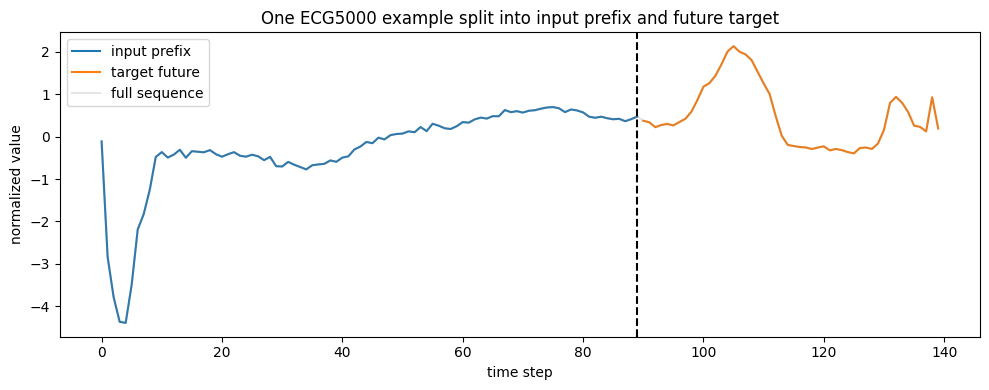

In [5]:
# ---------------------------------------
# Turn each full ECG sequence into:
#   x_i = observed prefix
#   y_i = future suffix

T_total = X_train_norm.shape[1]  # should be 140
T_x = 90
T_y = T_total - T_x

assert T_total == 140, f"Expected sequence length 140, got {T_total}"
assert T_y > 0, "Target suffix length must be positive."

# Input sequences: first T_x steps
X_train = X_train_norm[:, :T_x]
X_test = X_test_norm[:, :T_x]

# Target output sequences: final T_y steps
Y_train = X_train_norm[:, T_x:]
Y_test = X_test_norm[:, T_x:]

# Add a feature dimension F = 1 because the ECG is univariate
X_train = X_train[:, :, None]  # [N, T_x, 1]
X_test = X_test[:, :, None]    # [N, T_x, 1]
Y_train = Y_train[:, :, None]  # [N, T_y, 1]
Y_test = Y_test[:, :, None]    # [N, T_y, 1]

print("Input train shape X_train:", X_train.shape)
print("Target train shape Y_train:", Y_train.shape)
print("Input test shape  X_test: ", X_test.shape)
print("Target test shape Y_test: ", Y_test.shape)

print(f"T_x = {T_x}, T_y = {T_y}, F_x = {X_train.shape[2]}, F_y = {Y_train.shape[2]}")

# Quick sanity-check plot
example_idx = 0
full_example = np.concatenate(
    [X_train[example_idx, :, 0], Y_train[example_idx, :, 0]],
    axis=0
)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(T_x), X_train[example_idx, :, 0], label="input prefix")
plt.plot(np.arange(T_x, T_x + T_y), Y_train[example_idx, :, 0], label="target future")
plt.plot(np.arange(T_total), full_example, alpha=0.2, color="gray", label="full sequence")
plt.axvline(T_x - 1, linestyle="--", color="black")
plt.title("One ECG5000 example split into input prefix and future target")
plt.xlabel("time step")
plt.ylabel("normalized value")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Set up the DataLoader for training/validation/testing

All input sequences here have the same input length `T_x`, and all target sequences have the same output length `T_y`.  
So batching is straightforward.

Typical batch shapes are:

- `x in [B, T_x, F_x]`
- `y in [B, T_y, F_y]`

We will make a validation split from the training set.

In [7]:

# ---------------------------------------
# 3) Set up TensorDatasets and DataLoaders
# ---------------------------------------

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

# Build train dataset
full_train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# Split original training set into train/validation
val_fraction = 0.2
n_total = len(full_train_dataset)
n_val = int(n_total * val_fraction)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

In [8]:
BATCH_SIZE = 64 # you can change this ofc

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

# Quick sanity check: inspect one batch
for x_batch, y_batch in train_loader:
    break

print("x_batch shape:", x_batch.shape)  # [B, T_x, F_x]
print("y_batch shape:", y_batch.shape)  # [B, T_y, F_y]

Train size: 4000
Val size:   1000
Test size:  4500
x_batch shape: torch.Size([64, 90, 1])
y_batch shape: torch.Size([64, 50, 1])


## 4. Build the autoregressive seq2seq + attention model

This model has **4 parts**.

### A) Encoder
Reads the input sequence and outputs **all encoder hidden states**:

`x -> [RNN / GRU / LSTM encoder] -> H`

where:

- `x in [B, T_x, F_x]`
- `H = [h_1, ..., h_Tx] in [B, T_x, d_h]`

Unlike plain seq2seq, we keep **all** encoder hidden states.

### B) Attention
At decoder step `tau`, we compare the current decoder state with every encoder state:

- `e_(tau,j) = F(s_(tau-1), h_j)`   (relevance score)
- `alpha_(tau,j) = softmax_j(e_(tau,j))`   (attention weight)
- `c_tau = sum_j alpha_(tau,j) h_j`   (context vector)

### C) Decoder
Generates one output step at a time using:

- previous decoder state
- previous output
- current context vector

### D) Output head
Maps the decoder state to the current prediction.

In [9]:

# ---------------------------------------
# 4) Build an encoder-decoder model with attention
# ---------------------------------------

class Encoder(nn.Module):
    """Recurrent encoder: reads the input sequence and returns all encoder states."""

    def __init__(self, input_size: int, hidden_size: int, model_type: str = "GRU"):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size

        if self.model_type == "RNN":
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif self.model_type == "GRU":
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        elif self.model_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError("model_type must be one of: 'RNN', 'GRU', 'LSTM'")

    def forward(self, x):
        """
        x shape: [B, T_x, F_x]

        Returns:
        - encoder_outputs: [B, T_x, H], hidden states for all time steps
        - h_n (and c_n for LSTM): final hidden state(s) for each layer,
          used to initialize the decoder

        Note:
        h_n is indexed by layer, not by time. So h_n[-1] is the final
        hidden state of the last layer, not the full sequence
        [h_1, ..., h_T].
        """
        if self.model_type == "LSTM":
            encoder_outputs, (h_n, c_n) = self.rnn(x)
            return encoder_outputs, (h_n, c_n)
        else:
            encoder_outputs, h_n = self.rnn(x)
            return encoder_outputs, h_n


class AdditiveAttention(nn.Module):
    """Bahdanau-style additive attention."""

    def __init__(self, hidden_size: int):
        super().__init__()
        self.W_s = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_h = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, decoder_state, encoder_outputs):
        """
        decoder_state:  [B, H]
        encoder_outputs: [B, T_x, H]

        Returns:
        - context:          [B, H]
        - attention_weights [B, T_x]
        - attention_scores  [B, T_x]
        """
        # Score each encoder position against the current decoder state
        # e_(tau,j) = v^T tanh(W_s s_(tau-1) + W_h h_j)
        score_inputs = torch.tanh(
            self.W_s(decoder_state).unsqueeze(1) + self.W_h(encoder_outputs)
        )  # [B, T_x, H]

        attention_scores = self.v(score_inputs).squeeze(-1)  # [B, T_x]

        # Normalize scores across encoder positions
        attention_weights = torch.softmax(attention_scores, dim=1)  # [B, T_x]

        # Weighted sum of encoder states -> context
        context = torch.bmm(
            attention_weights.unsqueeze(1),  # [B, 1, T_x]
            encoder_outputs                  # [B, T_x, H]
        ).squeeze(1)                        # [B, H]

        return context, attention_weights, attention_scores


class Decoder(nn.Module):
    """Autoregressive decoder with attention-conditioned recurrent input."""

    def __init__(self, output_size: int, hidden_size: int, model_type: str = "GRU"):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size

        # The decoder sees:
        #   previous output step + current attention context
        decoder_input_size = output_size + hidden_size

        if self.model_type == "RNN":
            self.rnn = nn.RNN(decoder_input_size, hidden_size, batch_first=True)
        elif self.model_type == "GRU":
            self.rnn = nn.GRU(decoder_input_size, hidden_size, batch_first=True)
        elif self.model_type == "LSTM":
            self.rnn = nn.LSTM(decoder_input_size, hidden_size, batch_first=True)
        else:
            raise ValueError("model_type must be one of: 'RNN', 'GRU', 'LSTM'")

        # Output head: current decoder state -> predicted output step
        self.output_head = nn.Linear(hidden_size, output_size)

    def get_current_state(self, hidden):
        """Extract the current decoder hidden state s_(tau-1)."""
        if self.model_type == "LSTM":
            h_n, c_n = hidden
            return h_n[-1]   # [B, H]
        else:
            return hidden[-1]  # [B, H]

    def forward_step(self, decoder_input, hidden, context):
        """
        decoder_input: [B, 1, F_y]
        hidden: recurrent hidden state(s)
        context: [B, H]

        Returns:
        - pred_t: [B, 1, F_y]
        - updated hidden state
        """
        # Feed previous output together with current context
        rnn_input = torch.cat([decoder_input, context.unsqueeze(1)], dim=-1)  # [B, 1, F_y + H]
        output, hidden = self.rnn(rnn_input, hidden)  # output: [B, 1, H]

        pred_t = self.output_head(output)  # [B, 1, F_y]
        return pred_t, hidden


class EncoderDecoderAttentionForecaster(nn.Module):
    """Encoder-decoder recurrent forecaster with attention."""

    def __init__(self, input_size: int, output_size: int, hidden_size: int, model_type: str = "GRU"):
        super().__init__()
        self.model_type = model_type.upper()
        self.output_size = output_size

        self.encoder = Encoder(input_size=input_size, hidden_size=hidden_size, model_type=model_type)
        self.attention = AdditiveAttention(hidden_size=hidden_size)
        self.decoder = Decoder(output_size=output_size, hidden_size=hidden_size, model_type=model_type)

        # If input_size != output_size, project the last observed input into decoder space.
        self.start_projection = nn.Linear(input_size, output_size)

    def forward(self, x, target_seq=None, teacher_forcing_ratio=0.0, return_attention=False):
        """
        x shape: [B, T_x, F_x]
        target_seq shape: [B, T_y, F_y] or None

        Returns:
        - predictions: [B, T_y, F_y]
        - optionally attention weights: [B, T_y, T_x]
        """
        if target_seq is None:
            raise ValueError("For this notebook, target_seq must be provided to define decoder length.")

        # A) Encoder reads the input and returns all encoder states
        encoder_outputs, hidden = self.encoder(x)  # encoder_outputs: [B, T_x, H]
        T_y = target_seq.size(1)

        # Start token for continuous forecasting:
        # use the last observed input value, projected into output space if needed
        decoder_input = self.start_projection(x[:, -1, :]).unsqueeze(1)  # [B, 1, F_y]

        all_predictions = []
        all_attention_weights = []

        # B) Autoregressive rollout over decoder time
        for t in range(T_y):
            # Current decoder state s_(tau-1)
            current_decoder_state = self.decoder.get_current_state(hidden)  # [B, H]

            # Attention over all encoder states
            context, attn_weights, attn_scores = self.attention(
                decoder_state=current_decoder_state,
                encoder_outputs=encoder_outputs
            )

            # One decoder step
            pred_t, hidden = self.decoder.forward_step(
                decoder_input=decoder_input,
                hidden=hidden,
                context=context
            )

            all_predictions.append(pred_t)
            all_attention_weights.append(attn_weights.unsqueeze(1))  # [B, 1, T_x]

            # Teacher forcing or autoregressive feedback
            use_teacher = random.random() < teacher_forcing_ratio
            if use_teacher:
                decoder_input = target_seq[:, t:t+1, :]
            else:
                decoder_input = pred_t.detach()

        predictions = torch.cat(all_predictions, dim=1)  # [B, T_y, F_y]
        attention_map = torch.cat(all_attention_weights, dim=1)  # [B, T_y, T_x]

        if return_attention:
            return predictions, attention_map
        return predictions

In [10]:

# ---------------------------------------
# Instantiate the autoregressive attention model
# ---------------------------------------
INPUT_SIZE = X_train.shape[2]   # F_x = 1
OUTPUT_SIZE = Y_train.shape[2]  # F_y = 1
HIDDEN_SIZE = 64
MODEL_TYPE = "GRU"              # try: "RNN", "GRU", "LSTM"

model = EncoderDecoderAttentionForecaster(
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    model_type=MODEL_TYPE,
).to(device)

print(model)

# Quick forward-shape check
with torch.no_grad():
    dummy_pred, dummy_attn = model(
        x_batch.to(device),
        target_seq=y_batch.to(device),
        teacher_forcing_ratio=0.0,
        return_attention=True,
    )

print("Predicted sequence shape:", dummy_pred.shape)      # [B, T_y, F_y]
print("Attention map shape:     ", dummy_attn.shape)      # [B, T_y, T_x]

EncoderDecoderAttentionForecaster(
  (encoder): Encoder(
    (rnn): GRU(1, 64, batch_first=True)
  )
  (attention): AdditiveAttention(
    (W_s): Linear(in_features=64, out_features=64, bias=False)
    (W_h): Linear(in_features=64, out_features=64, bias=False)
    (v): Linear(in_features=64, out_features=1, bias=False)
  )
  (decoder): Decoder(
    (rnn): GRU(65, 64, batch_first=True)
    (output_head): Linear(in_features=64, out_features=1, bias=True)
  )
  (start_projection): Linear(in_features=1, out_features=1, bias=True)
)
Predicted sequence shape: torch.Size([64, 50, 1])
Attention map shape:      torch.Size([64, 50, 90])


## 5. Define a proper loss function based on `Y`

Here the target output sequence is **continuous**, so we use a regression loss.

For this autoregressive decoder, we compute loss over **all decoder time steps**.

Since all sequences here have the same target length, we do not need masking.

In [11]:

# ---------------------------------------
# 5) Define loss function and optimizer
# ---------------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6. Define the train and test functions

The encoder reads the input sequence and outputs **all encoder hidden states**.  
Then, at each decoder step, attention computes a **step-specific context vector** from those encoder states.

So the forward rollout is:

a- encoder reads the input sequence and outputs all encoder hidden states `H`  
b- at each decoder step `tau`, compute the context `c_tau` with attention over `H`  
c- update the decoder state  
d- generate output `y_hat_tau`

- **Training:** teacher forcing can be used by feeding the true previous target
- **Inference / evaluation:** use the model's own previous prediction

In [12]:

# ---------------------------------------
# 6) Define train / validation / test functions
# ---------------------------------------

def run_epoch(model, loader, criterion, optimizer=None, teacher_forcing_ratio=0.0):
    """Run one full pass over a loader."""
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            pred_batch = model(
                x_batch,
                target_seq=y_batch,
                teacher_forcing_ratio=teacher_forcing_ratio,
                return_attention=False,
            )
            loss = criterion(pred_batch, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = x_batch.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count


@torch.no_grad()
def predict_batch(model, x_batch, y_batch=None, return_attention=False):
    """Generate predictions with pure autoregressive decoding (no teacher forcing)."""
    model.eval()
    x_batch = x_batch.to(device)

    if y_batch is None:
        raise ValueError("For this notebook, y_batch is needed to define decoder length.")
    y_batch = y_batch.to(device)

    out = model(
        x_batch,
        target_seq=y_batch,
        teacher_forcing_ratio=0.0,
        return_attention=return_attention,
    )

    if return_attention:
        pred, attn = out
        return pred.cpu(), attn.cpu()
    else:
        return out.cpu()

## 7. Define training and run the training

We now run the standard training loop:

- train on the training set
- evaluate on the validation set
- save the best model
- inspect final predictions on the test set

Epoch 01 | train loss: 0.535948 | val loss: 0.350467
Epoch 02 | train loss: 0.460720 | val loss: 0.352322
Epoch 03 | train loss: 0.396898 | val loss: 0.330081
Epoch 04 | train loss: 0.266491 | val loss: 0.232201
Epoch 05 | train loss: 0.254976 | val loss: 0.239641
Epoch 06 | train loss: 0.243033 | val loss: 0.265426
Epoch 07 | train loss: 0.258312 | val loss: 0.224675
Epoch 08 | train loss: 0.210953 | val loss: 0.221896
Epoch 09 | train loss: 0.214915 | val loss: 0.241297
Epoch 10 | train loss: 0.217452 | val loss: 0.240882
Epoch 11 | train loss: 0.197059 | val loss: 0.204871
Epoch 12 | train loss: 0.193690 | val loss: 0.189088
Epoch 13 | train loss: 0.212776 | val loss: 0.192680
Epoch 14 | train loss: 0.192553 | val loss: 0.186107
Epoch 15 | train loss: 0.187910 | val loss: 0.175773
Epoch 16 | train loss: 0.178569 | val loss: 0.183791
Epoch 17 | train loss: 0.178909 | val loss: 0.181541
Epoch 18 | train loss: 0.186138 | val loss: 0.198373
Epoch 19 | train loss: 0.167406 | val loss: 0.

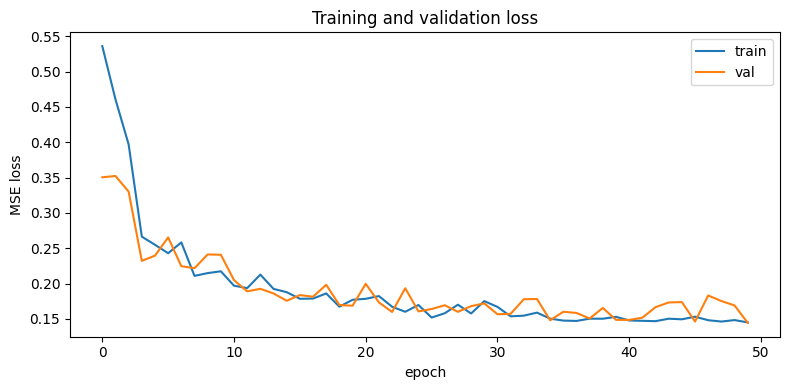

In [16]:

# ---------------------------------------
# 7) Train the model and inspect results
# ---------------------------------------
NUM_EPOCHS = 50
TEACHER_FORCING_RATIO = 0.0

best_val_loss = float("inf")
best_state_dict = None

train_losses = []
val_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO,
    )

    val_loss = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        teacher_forcing_ratio=0.0,
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:02d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

# Load the best validation model
model.load_state_dict(best_state_dict)

# Final test loss
test_loss = run_epoch(
    model,
    test_loader,
    criterion,
    optimizer=None,
    teacher_forcing_ratio=0.0,
)

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Test loss:     {test_loss:.6f}")

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

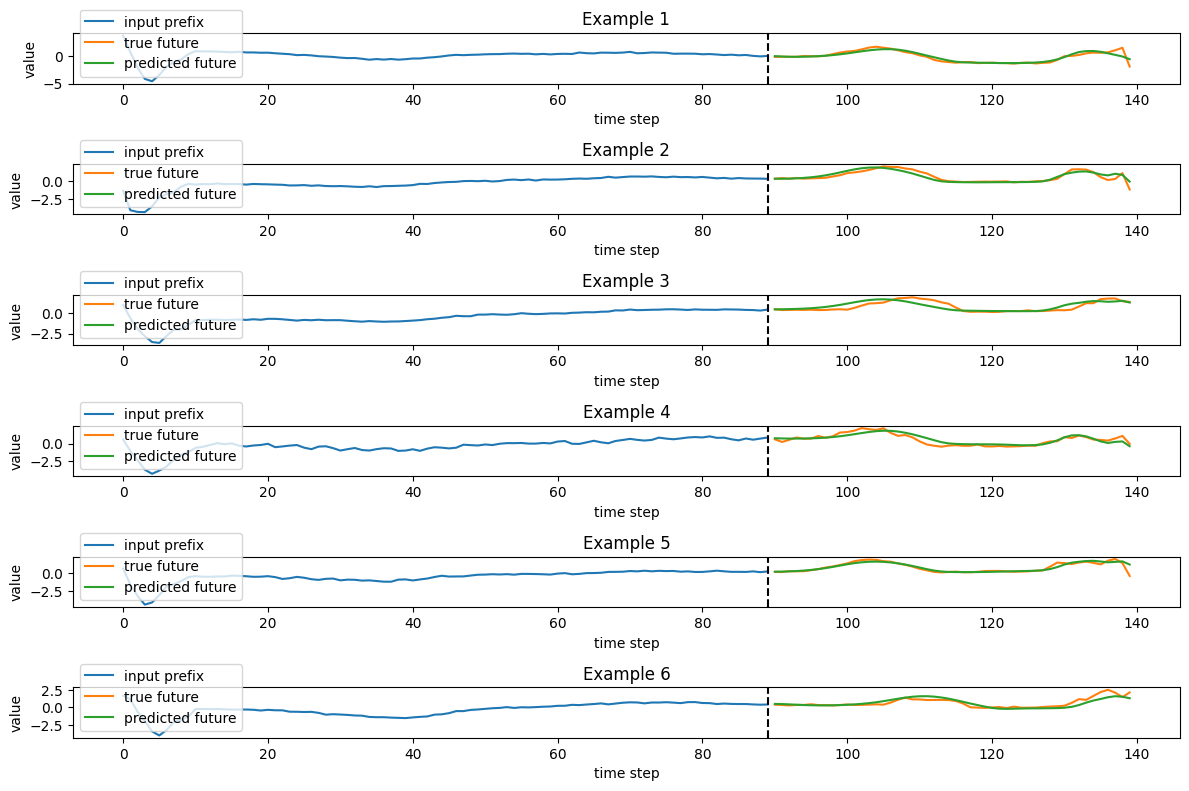

In [17]:

# ---------------------------------------
# Visualize a few autoregressive predictions on the test set
# ---------------------------------------
for x_vis, y_vis in test_loader:
    break

pred_vis, attn_vis = predict_batch(model, x_vis, y_vis, return_attention=True)

num_examples_to_show = 6
plt.figure(figsize=(12, 8))

for i in range(num_examples_to_show):
    prefix = x_vis[i, :, 0].numpy()
    target = y_vis[i, :, 0].numpy()
    pred   = pred_vis[i, :, 0].numpy()

    prefix_t = np.arange(T_x)
    future_t = np.arange(T_x, T_x + T_y)

    plt.subplot(num_examples_to_show, 1, i + 1)
    plt.plot(prefix_t, prefix, label="input prefix")
    plt.plot(future_t, target, label="true future")
    plt.plot(future_t, pred, label="predicted future")
    plt.axvline(T_x - 1, linestyle="--", color="black")
    plt.title(f"Example {i+1}")
    plt.xlabel("time step")
    plt.ylabel("value")
    plt.legend()

plt.tight_layout()
plt.show()

## Optional: inspect one attention map

Rows = decoder time steps  
Columns = encoder time steps

For this ECG forecasting task, attention is still meaningful to inspect, but the patterns may be subtler than in a text example.

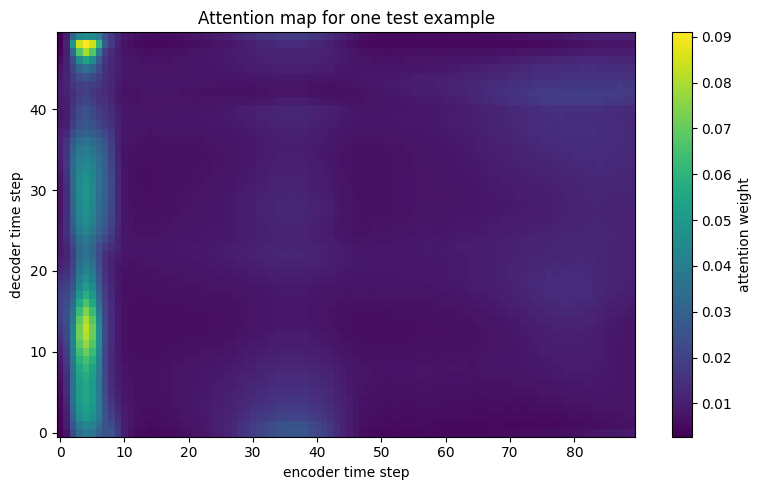

Attention row sums (should be ~1):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


In [22]:

# ---------------------------------------
# Visualize one attention map
# ---------------------------------------
example_idx = 50

plt.figure(figsize=(8, 5))
plt.imshow(attn_vis[example_idx].numpy(), aspect="auto", origin="lower")
plt.colorbar(label="attention weight")
plt.xlabel("encoder time step")
plt.ylabel("decoder time step")
plt.title("Attention map for one test example")
plt.tight_layout()
plt.show()

print("Attention row sums (should be ~1):")
print(attn_vis[example_idx].sum(dim=1)[:10])